In [32]:
import warnings
warnings.filterwarnings("ignore", message="numpy.dtype size changed")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gzip
import pickle

# ==========================================
# General Plotting Setup
# ==========================================
pd.options.mode.chained_assignment = None
plt.rcParams['figure.max_open_warning'] = 50
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"],
    "savefig.dpi": 300
})
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

sns.set_style('ticks', {'font.family': 'Times New Roman', 'font.serif': 'Times New Roman'})
sns.set_context('paper', font_scale=2.0)

colors = plt.cm.tab10.colors
color_map = {
    'SM': 'gray',
    'VLF': colors[2],
    'Scalar': colors[0],
    'Zprime': colors[3],
    'Zprime_20pc': 'cyan',
    'FakeData': 'black'
}
y_DM_dict = {'1-loop VLF': 3.97, '1-loop Scalar': 7.55}

# Data Structure

```text
all_plot_data (list of dict)
 └── plot_entry (dict)
      ├── 'bins'          : np.ndarray (float64)
      ├── 'h_sm'          : np.ndarray (float64)
      ├── 'hErr_sm'       : np.ndarray (float64)
      ├── 'mPsiT'         : float
      ├── 'mSDM'          : float
      ├── 'mZp'           : float
      ├── 'wZp'           : float
      ├── 'var'           : str
      ├── 'y_limits'      : tuple (float, float)
      ├── 'x_limits'      : tuple (float, float)
      ├── 'ratio_limits'  : list [float, float] or None
      ├── 'ratio_ticks'   : np.ndarray (float64)
      ├── 'y_label'       : str (LaTeX formatted)
      ├── 'x_label'       : str (LaTeX formatted)
      ├── 'filename'      : str
      └── 'bsm_items'     : list of dict
           └── bsm_entry (dict)
                ├── 'display_name' : str
                ├── 'val_y_dm'     : float or None
                ├── 'g_q'          : float or None (Z prime only)
                ├── 'g_t'          : float or None (Z prime only)
                ├── 'hist'         : np.ndarray (float64)
                └── 'err'          : np.ndarray (float64)
```

## Load Histograms and split into variable and process

In [33]:
file = './Differential_distributions_histograms.pkl.gz'
with gzip.open(file, 'rb') as f:
    all_plot_data = pickle.load(f)
qq_data = {data['x_label'] : data for data in all_plot_data if 'qq' in data['process']}
pp_data = {data['x_label'] : data for data in all_plot_data if 'qq' not in data['process']}

### Check total cross-sections

In [34]:
print('qq -> tt:')
for key in qq_data:
    print('\t',key)
    h_sm = qq_data[key]['h_sm']
    bsm_hists = qq_data[key]['bsm_items']  
    print(f'\t\tSM xsec = {h_sm.sum():1.3e} pb')
    for entry in bsm_hists:
        print(f'\t\t{entry["display_name"]} xsec = {entry["hist"].sum():1.3e} pb')

print('\npp -> tt:')
for key in pp_data:
    print('\t',key)
    h_sm = pp_data[key]['h_sm']
    bsm_hists = pp_data[key]['bsm_items']
    print(f'\t\tSM xsec = {h_sm.sum():1.3e} pb')
    for entry in bsm_hists:
        print(f'\t\t{entry["display_name"]} xsec = {entry["hist"].sum():1.3e} pb')        

qq -> tt:
	 $m(t\bar{t})$ (GeV)
		SM xsec = 6.421e+01 pb
		Scalar xsec = 5.979e-02 pb
		VLF xsec = 9.399e-02 pb
		Zprime xsec = 9.596e-04 pb

pp -> tt:
	 $m(t\bar{t})$ (GeV)
		SM xsec = 4.625e+02 pb
		Scalar xsec = -3.950e-01 pb
		VLF xsec = 1.969e-01 pb
		Zprime xsec = 9.596e-04 pb
	 $p_T(t)$ (GeV)
		SM xsec = 4.625e+02 pb
		Scalar xsec = -3.950e-01 pb
		VLF xsec = 1.969e-01 pb
		Zprime xsec = 9.596e-04 pb
	 $\cos{\theta^*} $
		SM xsec = 4.625e+02 pb
		Scalar xsec = -3.950e-01 pb
		VLF xsec = 1.969e-01 pb
		Zprime xsec = 9.596e-04 pb


## Distributions

### Invariant Mass

#### qq -> tt

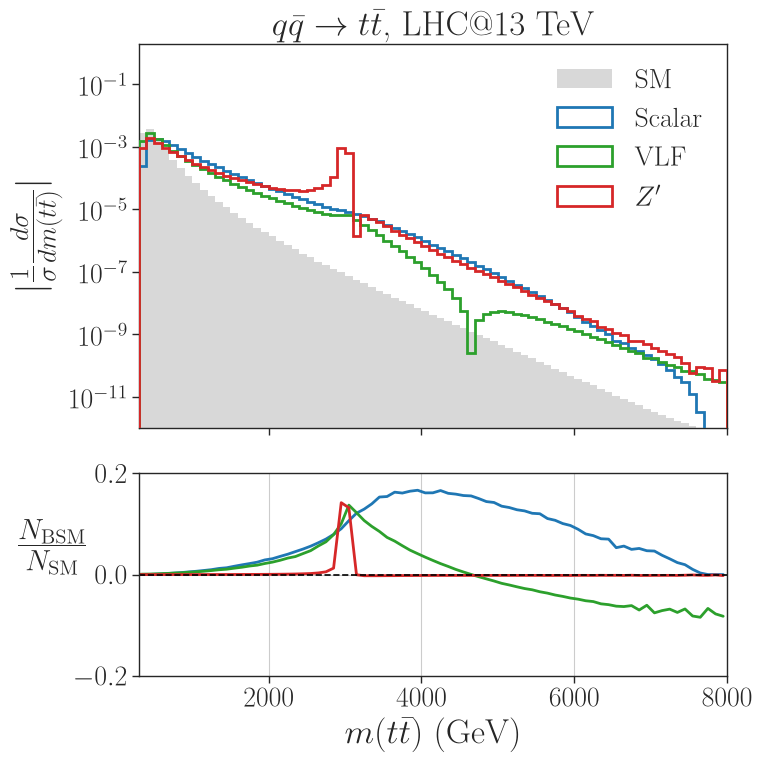

Generated plot: Dists_comparison_qq.png


In [35]:
entry = qq_data['$m(t\\bar{t})$ (GeV)']
bins = entry['bins']
x_centers = (bins[:-1] + bins[1:]) / 2.0
h_sm = entry['h_sm']
hErr_sm = entry['hErr_sm']
bsm_items = entry['bsm_items']

fig, axarr = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': [1.9, 1]}, figsize=(8, 8))
plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, hspace=0.1)

# 1. Plot SM
axarr[0].hist(bins[:-1], weights=np.abs(h_sm), bins=bins, density=True,
                color=color_map['SM'], alpha=0.3, histtype='step', 
                linewidth=0.0, fill=True, zorder=0, label='SM')

bsm_hists, bsm_errs, bsm_labels = [], [], []

# 2. Plot BSM & Z'
for item in bsm_items:
    display_name = item['display_name']
    h_bsm = item['hist']
    hErr_bsm = item['err']
    
    bsm_hists.append(h_bsm)
    bsm_errs.append(hErr_bsm)
    bsm_labels.append(display_name)

    if display_name == 'Zprime':
        label_str = r'$Z^\prime$'
    else:
        label_str = rf'{display_name}'

    axarr[0].hist(bins[:-1], weights=np.abs(h_bsm), bins=bins, density=True,
                    color=color_map[display_name], alpha=1.0, histtype='step', 
                    linewidth=2, fill=False, zorder=3, label=label_str)

# 3. Ratio Subplot Calculations
with np.errstate(divide='ignore', invalid='ignore'):
    raw_ratio = np.nan_to_num(np.array(bsm_hists) / h_sm)
    err_bsm_rel = np.nan_to_num(np.array(bsm_errs) / np.array(bsm_hists))
    err_sm_rel = np.nan_to_num(hErr_sm / h_sm)
    ratio_err = np.abs(raw_ratio) * np.sqrt(err_bsm_rel**2 + err_sm_rel**2)

for k, r in enumerate(raw_ratio):
    # axarr[1].errorbar(x_centers, r, yerr=ratio_err[k], color=color_map[bsm_labels[k]], 
                        # fmt='o', ms=3, capsize=3.5, label=bsm_labels[k])
    axarr[1].plot(x_centers, r, color=color_map[bsm_labels[k]],linewidth=2)

axarr[0].set_title(r"$q \bar{q} \to t \bar{t}$, LHC@13 TeV", fontsize=25)
axarr[0].legend(framealpha=0.0, ncol=1, loc='upper right' if entry['var'] != 'cost*' else 'upper center', fontsize=20)
axarr[0].set_yscale('log')
axarr[0].set_ylabel(entry['y_label'], fontsize=27)
axarr[0].set_xlim(bins.min(), bins.max())
axarr[0].set_ylim(entry['y_limits'])
axarr[0].set_xlim(entry['x_limits'])
axarr[0].tick_params(axis='both', width=1, labelsize=20)

axarr[1].axhline(y=0, color='k', linestyle='--')
axarr[1].set_ylabel(r'$\frac{N_{\mathrm{BSM}}}{ N_{\mathrm{SM}}}$', fontsize=30, rotation=0, labelpad=15) 
axarr[1].set_xlabel(entry['x_label'], fontsize=25)
axarr[1].set_ylim(entry['ratio_limits'])
axarr[1].set_yticks(entry['ratio_ticks'])
axarr[1].set_xlim(entry['x_limits'])
axarr[1].grid(True)
axarr[1].tick_params(axis='both', width=1, labelsize=20)

plt.tight_layout()
plt.savefig(entry['filename'])
plt.show()
print(f"Generated plot: {entry['filename']}")

#### pp - > tt

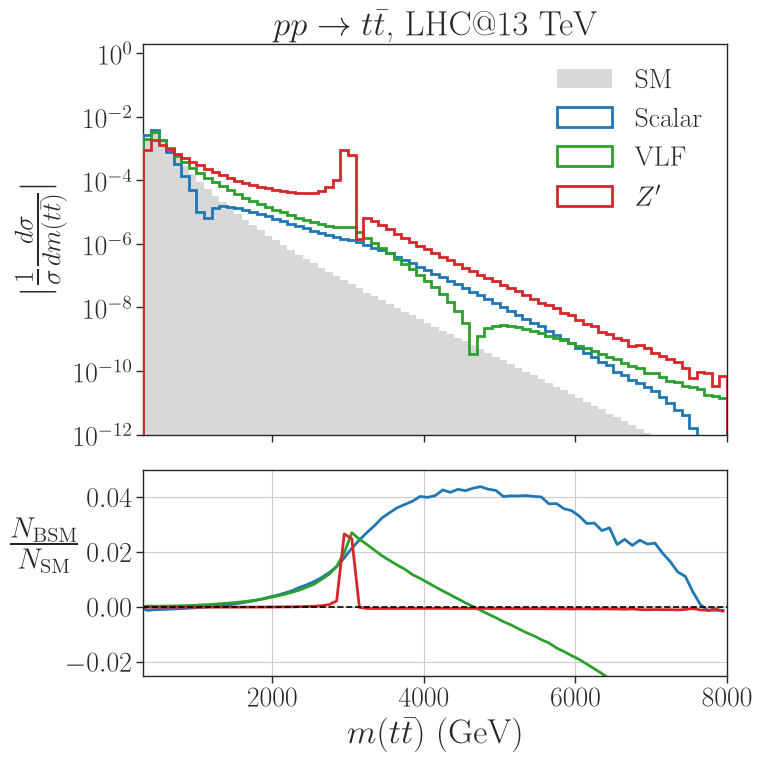

Generated plot: Dists_comparison_interference.png


In [36]:
entry = pp_data['$m(t\\bar{t})$ (GeV)']
bins = entry['bins']
x_centers = (bins[:-1] + bins[1:]) / 2.0
h_sm = entry['h_sm']
hErr_sm = entry['hErr_sm']
bsm_items = entry['bsm_items']

fig, axarr = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': [1.9, 1]}, figsize=(8, 8))
plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, hspace=0.1)

# 1. Plot SM
axarr[0].hist(bins[:-1], weights=np.abs(h_sm), bins=bins, density=True,
                color=color_map['SM'], alpha=0.3, histtype='step', 
                linewidth=0.0, fill=True, zorder=0, label='SM')

bsm_hists, bsm_errs, bsm_labels = [], [], []

# 2. Plot BSM & Z'
for item in bsm_items:
    display_name = item['display_name']
    h_bsm = item['hist']
    hErr_bsm = item['err']
    
    bsm_hists.append(h_bsm)
    bsm_errs.append(hErr_bsm)
    bsm_labels.append(display_name)

    if display_name == 'Zprime':
        label_str = r'$Z^\prime$'
    else:
        label_str = rf'{display_name}'

    axarr[0].hist(bins[:-1], weights=np.abs(h_bsm), bins=bins, density=True,
                    color=color_map[display_name], alpha=1.0, histtype='step', 
                    linewidth=2, fill=False, zorder=3, label=label_str)

# 3. Ratio Subplot Calculations
with np.errstate(divide='ignore', invalid='ignore'):
    raw_ratio = np.nan_to_num(np.array(bsm_hists) / h_sm)
    err_bsm_rel = np.nan_to_num(np.array(bsm_errs) / np.array(bsm_hists))
    err_sm_rel = np.nan_to_num(hErr_sm / h_sm)
    ratio_err = np.abs(raw_ratio) * np.sqrt(err_bsm_rel**2 + err_sm_rel**2)

for k, r in enumerate(raw_ratio):
    # axarr[1].errorbar(x_centers, r, yerr=ratio_err[k], color=color_map[bsm_labels[k]], 
                        # fmt='o', ms=3, capsize=3.5, label=bsm_labels[k])
    axarr[1].plot(x_centers, r, color=color_map[bsm_labels[k]],linewidth=2)

axarr[0].set_title(r"$p p \to t \bar{t}$, LHC@13 TeV", fontsize=25)
axarr[0].legend(framealpha=0.0, ncol=1, loc='upper right' if entry['var'] != 'cost*' else 'upper center', fontsize=20)
axarr[0].set_yscale('log')
axarr[0].set_ylabel(entry['y_label'], fontsize=27)
axarr[0].set_xlim(bins.min(), bins.max())
axarr[0].set_ylim(entry['y_limits'])
axarr[0].set_xlim(entry['x_limits'])
axarr[0].tick_params(axis='both', width=1, labelsize=20)

axarr[1].axhline(y=0, color='k', linestyle='--')
axarr[1].set_ylabel(r'$\frac{N_{\mathrm{BSM}}}{ N_{\mathrm{SM}}}$', fontsize=30, rotation=0, labelpad=15) 
axarr[1].set_xlabel(entry['x_label'], fontsize=25)
axarr[1].set_ylim(entry['ratio_limits'])
axarr[1].set_yticks(entry['ratio_ticks'])
axarr[1].set_xlim(entry['x_limits'])
axarr[1].grid(True)
axarr[1].tick_params(axis='both', width=1, labelsize=20)

plt.tight_layout()
plt.savefig(entry['filename'])
plt.show()
print(f"Generated plot: {entry['filename']}")

### Transverse Momentum

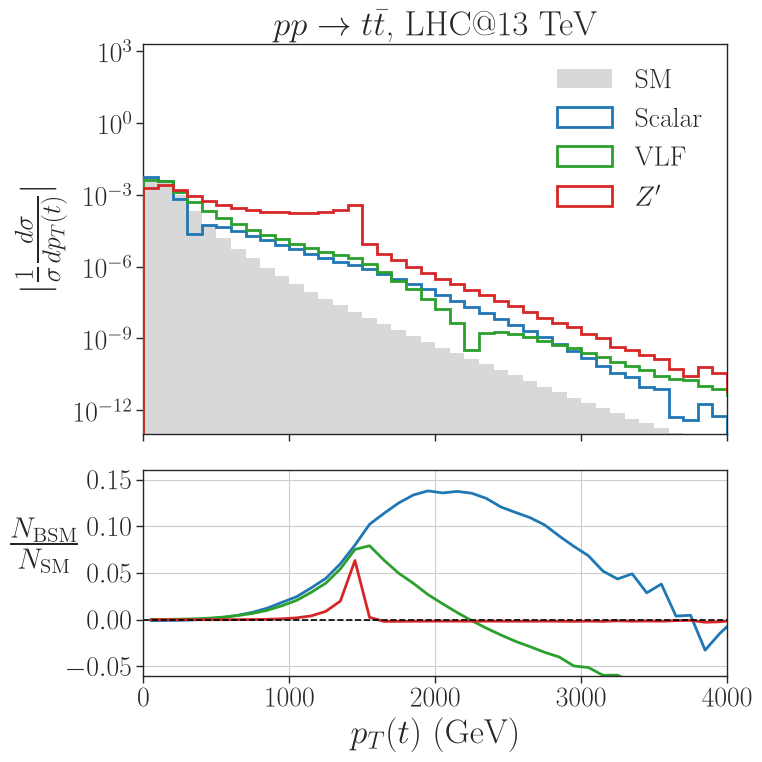

Generated plot: Dists_comparison_pT.png


In [37]:
entry = pp_data['$p_T(t)$ (GeV)']
bins = entry['bins']
x_centers = (bins[:-1] + bins[1:]) / 2.0
h_sm = entry['h_sm']
hErr_sm = entry['hErr_sm']
bsm_items = entry['bsm_items']

fig, axarr = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': [1.9, 1]}, figsize=(8, 8))
plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, hspace=0.1)

# 1. Plot SM
axarr[0].hist(bins[:-1], weights=np.abs(h_sm), bins=bins, density=True,
                color=color_map['SM'], alpha=0.3, histtype='step', 
                linewidth=0.0, fill=True, zorder=0, label='SM')

bsm_hists, bsm_errs, bsm_labels = [], [], []

# 2. Plot BSM & Z'
for item in bsm_items:
    display_name = item['display_name']
    h_bsm = item['hist']
    hErr_bsm = item['err']
    
    bsm_hists.append(h_bsm)
    bsm_errs.append(hErr_bsm)
    bsm_labels.append(display_name)

    if display_name == 'Zprime':
        label_str = r'$Z^\prime$'
    else:
        label_str = rf'{display_name}'

    axarr[0].hist(bins[:-1], weights=np.abs(h_bsm), bins=bins, density=True,
                    color=color_map[display_name], alpha=1.0, histtype='step', 
                    linewidth=2, fill=False, zorder=3, label=label_str)

# 3. Ratio Subplot Calculations
with np.errstate(divide='ignore', invalid='ignore'):
    raw_ratio = np.nan_to_num(np.array(bsm_hists) / h_sm)
    err_bsm_rel = np.nan_to_num(np.array(bsm_errs) / np.array(bsm_hists))
    err_sm_rel = np.nan_to_num(hErr_sm / h_sm)
    ratio_err = np.abs(raw_ratio) * np.sqrt(err_bsm_rel**2 + err_sm_rel**2)

for k, r in enumerate(raw_ratio):
    # axarr[1].errorbar(x_centers, r, yerr=ratio_err[k], color=color_map[bsm_labels[k]], 
                        # fmt='o', ms=3, capsize=3.5, label=bsm_labels[k])
    axarr[1].plot(x_centers, r, color=color_map[bsm_labels[k]],linewidth=2)

axarr[0].set_title(r"$p p \to t \bar{t}$, LHC@13 TeV", fontsize=25)
axarr[0].legend(framealpha=0.0, ncol=1, loc='upper right' if entry['var'] != 'cost*' else 'upper center', fontsize=20)
axarr[0].set_yscale('log')
axarr[0].set_ylabel(entry['y_label'], fontsize=27)
axarr[0].set_xlim(bins.min(), bins.max())
axarr[0].set_ylim(entry['y_limits'])
axarr[0].set_xlim(entry['x_limits'])
axarr[0].tick_params(axis='both', width=1, labelsize=20)

axarr[1].axhline(y=0, color='k', linestyle='--')
axarr[1].set_ylabel(r'$\frac{N_{\mathrm{BSM}}}{ N_{\mathrm{SM}}}$', fontsize=30, rotation=0, labelpad=15) 
axarr[1].set_xlabel(entry['x_label'], fontsize=25)
axarr[1].set_ylim(entry['ratio_limits'])
axarr[1].set_yticks(entry['ratio_ticks'])
axarr[1].set_xlim(entry['x_limits'])
axarr[1].grid(True)
axarr[1].tick_params(axis='both', width=1, labelsize=20)

plt.tight_layout()
plt.savefig(entry['filename'])
plt.show()
print(f"Generated plot: {entry['filename']}")

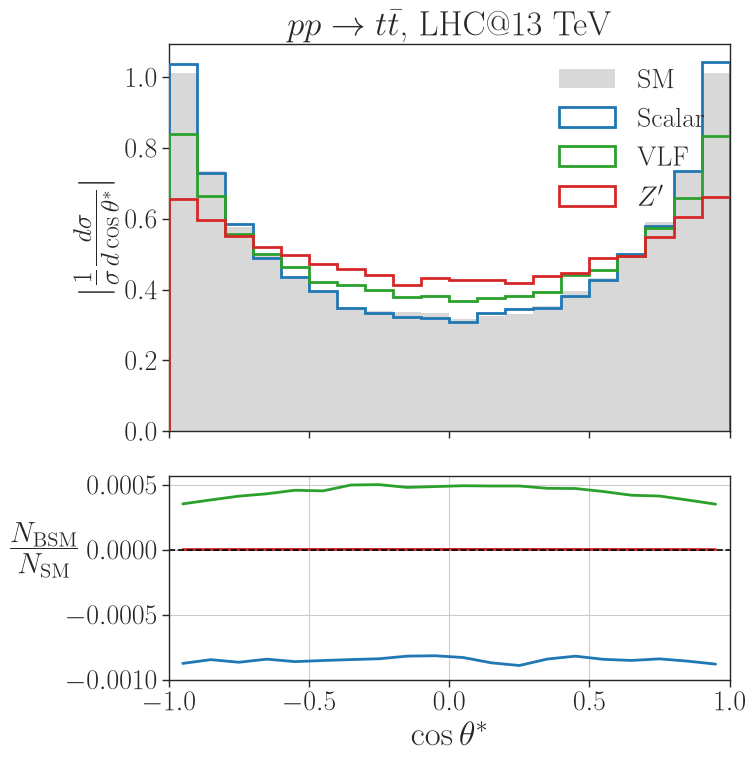

Generated plot: Dists_comparison_cost.png


In [38]:
entry = pp_data['$\\cos{\\theta^*} $']
bins = entry['bins']
x_centers = (bins[:-1] + bins[1:]) / 2.0
h_sm = entry['h_sm']
hErr_sm = entry['hErr_sm']
bsm_items = entry['bsm_items']

fig, axarr = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': [1.9, 1]}, figsize=(8, 8))
plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, hspace=0.1)

# 1. Plot SM
axarr[0].hist(bins[:-1], weights=np.abs(h_sm), bins=bins, density=True,
                color=color_map['SM'], alpha=0.3, histtype='step', 
                linewidth=0.0, fill=True, zorder=0, label='SM')

bsm_hists, bsm_errs, bsm_labels = [], [], []

# 2. Plot BSM & Z'
for item in bsm_items:
    display_name = item['display_name']
    h_bsm = item['hist']
    hErr_bsm = item['err']
    
    bsm_hists.append(h_bsm)
    bsm_errs.append(hErr_bsm)
    bsm_labels.append(display_name)

    if display_name == 'Zprime':
        label_str = r'$Z^\prime$'
    else:
        label_str = rf'{display_name}'

    axarr[0].hist(bins[:-1], weights=np.abs(h_bsm), bins=bins, density=True,
                    color=color_map[display_name], alpha=1.0, histtype='step', 
                    linewidth=2, fill=False, zorder=3, label=label_str)

# 3. Ratio Subplot Calculations
with np.errstate(divide='ignore', invalid='ignore'):
    raw_ratio = np.nan_to_num(np.array(bsm_hists) / h_sm)
    err_bsm_rel = np.nan_to_num(np.array(bsm_errs) / np.array(bsm_hists))
    err_sm_rel = np.nan_to_num(hErr_sm / h_sm)
    ratio_err = np.abs(raw_ratio) * np.sqrt(err_bsm_rel**2 + err_sm_rel**2)

for k, r in enumerate(raw_ratio):
    # axarr[1].errorbar(x_centers, r, yerr=ratio_err[k], color=color_map[bsm_labels[k]], 
                        # fmt='o', ms=3, capsize=3.5, label=bsm_labels[k])
    axarr[1].plot(x_centers, r, color=color_map[bsm_labels[k]],linewidth=2)

axarr[0].set_title(r"$p p \to t \bar{t}$, LHC@13 TeV", fontsize=25)
axarr[0].legend(framealpha=0.0, ncol=1, loc='upper right', fontsize=20)
# axarr[0].set_yscale('log')
axarr[0].set_ylabel(entry['y_label'], fontsize=27)
axarr[0].set_xlim(bins.min(), bins.max())
# axarr[0].set_ylim(1e-3,1e4)
axarr[0].set_xlim(entry['x_limits'])
axarr[0].tick_params(axis='both', width=1, labelsize=20)

axarr[1].axhline(y=0, color='k', linestyle='--')
axarr[1].set_ylabel(r'$\frac{N_{\mathrm{BSM}}}{ N_{\mathrm{SM}}}$', fontsize=30, rotation=0, labelpad=15) 
axarr[1].set_xlabel(entry['x_label'], fontsize=25)
axarr[1].set_ylim(entry['ratio_limits'])
axarr[1].set_xlim(entry['x_limits'])
axarr[1].set_yticks(entry['ratio_ticks'])
axarr[1].grid(True)
axarr[1].tick_params(axis='both', width=1, labelsize=20)

plt.tight_layout()
plt.savefig(entry['filename'])
plt.show()
print(f"Generated plot: {entry['filename']}")